<a href="https://colab.research.google.com/github/ghalia543/ecommerce-marketing-analytics/blob/main/notebooks/01_Data_Understanding_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
file_name = 'ecommerce_dataset_+1m.csv'

df = pd.read_csv(file_name)

In [ ]:
df.head()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,return_reason,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date,product_id,product_name,category,sub_category,brand,product_rating_avg,product_reviews_count,stock_quantity,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,tax_usd,currency,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,rating,review_sentiment,customer_feedback,coupon_used,coupon_code,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,NaN,CUS-6DPBH,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.00,38,2022-04-23,PRD-1FPK,Coffee Maker Automatic,Home,Kitchen,Nike,3.20,3112,99,120.51,3,10,36.15,325.38,232.14,93.24,28.14,USD,Apple Pay,Paid,No,Economy,1.97,5,Netherlands,UK,In Transit,3,Neutral,NaN,Yes,CPN-ZBI,Email,Mobile,Search,52.10,13,No,45.30,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,NaN,CUS-G0FN9,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.20,21,2022-08-22,PRD-C6UZ,Yoga Mat Non-Slip,Health,Supplements,Asus,3.80,3758,146,60.33,2,15,18.10,102.56,67.78,34.78,8.96,USD,Bank Transfer,Paid,Yes,Next Day,5.48,3,United States,UK,Delivered,1,Negative,Good value for money,Yes,CPN-W2P,Google Ads,Desktop,Referral,36.20,15,No,97.10,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,NaN,CUS-Q85JS,Jason Garcia,Male,50,VIP,France,Nice,60.90,10,2024-08-04,PRD-T2TA,Blender 1000W,Home,Furniture,Asus,3.00,2973,899,295.89,3,0,0.00,887.67,419.22,468.45,69.56,USD,Credit Card,Paid,No,Economy,20.40,13,France,UK,In Transit,2,Negative,Highly recommended,Yes,CPN-J5P,Facebook,Tablet,Search,43.10,13,No,43.80,52.77,High,No
3,ORD-EIMVI,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,NaN,CUS-CWI64,David Norris,Male,50,Regular,Italy,Milan,53.90,47,2023-08-06,PRD-IROD,Badminton Racket,Sports,Accessories,Adidas,3.80,3825,884,186.33,1,0,0.00,186.33,115.24,71.09,16.78,USD,Credit Card,Paid,No,Express,4.76,8,Italy,USA-West,Delivered,3,Neutral,Highly recommended,Yes,CPN-5C3,Instagram,Mobile,Direct,39.50,18,Yes,96.90,38.15,Low,Yes
4,ORD-OR56F,2025-05-21 17:10:48.401882,2025,5,21,17,10,48,No,Completed,NaN,CUS-O72KZ,Laura Phillips,Female,27,Regular,Germany,Berlin,57.90,35,2023-01-02,PRD-LBR7,Screen Protector Tempered Glass,Electronics,Cameras,Anker,3.10,4160,82,427.16,1,10,42.72,384.44,257.39,127.05,23.74,USD,Credit Card,Paid,No,Standard,15.48,7,Germany,UK,Delivered,3,Neutral,Average quality,Yes,CPN-YLJ,Facebook,Tablet,Social,28.00,3,Yes,45.80,33.05,High,Yes


In [ ]:

df.shape


(1000123, 62)

In [ ]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. order_id
2. order_date
3. order_year
4. order_month
5. order_day
6. order_hour
7. order_minute
8. order_second
9. is_weekend
10. order_status
11. return_reason
12. customer_id
13. customer_name
14. gender
15. age
16. customer_segment
17. country
18. city
19. customer_loyalty_score
20. total_orders_by_customer
21. account_creation_date
22. product_id
23. product_name
24. category
25. sub_category
26. brand
27. product_rating_avg
28. product_reviews_count
29. stock_quantity
30. unit_price_usd
31. quantity
32. discount_percent
33. discount_amount_usd
34. total_price_usd
35. cost_usd
36. profit_usd
37. tax_usd
38. currency
39. payment_method
40. payment_status
41. installment_plan
42. shipping_method
43. shipping_cost_usd
44. delivery_days
45. shipping_country
46. warehouse_location
47. delivery_status
48. rating
49. review_sentiment
50. customer_feedback
51. coupon_used
52. coupon_code
53. campaign_source
54. device_type
55. traffic_source
56. session_duration_minutes
57. pages_visited

In [ ]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 62 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  object 
 1   order_date                1000123 non-null  object 
 2   order_year                1000123 non-null  int64  
 3   order_month               1000123 non-null  int64  
 4   order_day                 1000123 non-null  int64  
 5   order_hour                1000123 non-null  int64  
 6   order_minute              1000123 non-null  int64  
 7   order_second              1000123 non-null  int64  
 8   is_weekend                1000123 non-null  object 
 9   order_status              1000123 non-null  object 
 10  return_reason             99879 non-null    object 
 11  customer_id               1000123 non-null  object 
 12  customer_name             1000123 non-null  object 
 13  gender                    1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1000123,991930,ORD-2J3XB,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,1000123,1000123,2025-04-17 15:30:36.405483,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_year,"1,000,123.00",NaN,NaN,NaN,"2,024.59",0.58,"2,024.00","2,024.00","2,025.00","2,025.00","2,026.00"
order_month,"1,000,123.00",NaN,NaN,NaN,6.51,3.45,1.00,4.00,7.00,10.00,12.00
order_day,"1,000,123.00",NaN,NaN,NaN,15.75,8.80,1.00,8.00,16.00,23.00,31.00
order_hour,"1,000,123.00",NaN,NaN,NaN,11.49,6.92,0.00,5.00,11.00,17.00,23.00
order_minute,"1,000,123.00",NaN,NaN,NaN,29.49,17.31,0.00,14.00,30.00,44.00,59.00
order_second,"1,000,123.00",NaN,NaN,NaN,29.49,17.33,0.00,14.00,29.00,44.00,59.00
is_weekend,1000123,2,No,713021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,1000123,5,Completed,700232,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
profile = pd.DataFrame({
    'column': df.columns,
    'data_type': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_percent': (df.isna().mean() * 100).values,
    'unique_values': df.nunique(dropna=False).values
})

profile

,column,data_type,missing_count,missing_percent,unique_values
0,order_id,object,0,0.00,991930
1,order_date,object,0,0.00,1000123
2,order_year,int64,0,0.00,3
3,order_month,int64,0,0.00,12
4,order_day,int64,0,0.00,31
5,order_hour,int64,0,0.00,24
6,order_minute,int64,0,0.00,60
7,order_second,int64,0,0.00,60
8,is_weekend,object,0,0.00,2
9,order_status,object,0,0.00,5


In [ ]:
profile.sort_values(
    by='missing_percent',
    ascending=False
).head(20)

,column,data_type,missing_count,missing_percent,unique_values
10,return_reason,object,900244,90.01,6
51,coupon_code,object,500083,50.00,46657
49,customer_feedback,object,199617,19.96,9
3,order_month,int64,0,0.00,12
2,order_year,int64,0,0.00,3
0,order_id,object,0,0.00,991930
5,order_hour,int64,0,0.00,24
6,order_minute,int64,0,0.00,60
8,is_weekend,object,0,0.00,2
7,order_second,int64,0,0.00,60


In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [ ]:
print(f"Total rows: {len(df):,}")
print(f"Unique orders: {df['order_id'].nunique():,}")

Total rows: 1,000,123
Unique orders: 991,930


In [ ]:
order_duplicates = df['order_id'].duplicated().sum()

print(f"Rows with repeated order_id: {order_duplicates:,}")

Rows with repeated order_id: 8,193


In [ ]:
order_product_duplicates = df.duplicated(
    subset=['order_id', 'product_id']
).sum()

print(
    f"Duplicate order-product combinations: "
    f"{order_product_duplicates:,}"
)

Duplicate order-product combinations: 0


In [ ]:
categorical_columns = [
    'order_status',
    'gender',
    'customer_segment',
    'country',
    'category',
    'sub_category',
    'brand',
    'payment_method',
    'payment_status',
    'shipping_method',
    'delivery_status',
    'campaign_source',
    'device_type',
    'traffic_source',
    'coupon_used',
    'order_priority',
    'review_sentiment'
]

for column in categorical_columns:
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")
    print(df[column].value_counts(dropna=False).head(20))


order_status
order_status
Completed     700232
Returned       99879
Pending        99748
Cancelled      50163
Processing     50101
Name: count, dtype: int64

gender
gender
Male      500180
Female    499943
Name: count, dtype: int64

customer_segment
customer_segment
Regular    599295
Premium    300404
VIP        100424
Name: count, dtype: int64

country
country
Netherlands       100548
Belgium           100357
France            100147
United Kingdom    100064
Spain             100041
Canada            100023
Australia          99774
Italy              99761
United States      99742
Germany            99666
Name: count, dtype: int64

category
category
Home           200589
Sports         200397
Electronics    200019
Health         199574
Clothing       199544
Name: count, dtype: int64

sub_category
sub_category
Accessories        123702
Supplements         50142
Gym Equipment       50141
Personal Care       50039
Sports Wear         49957
Medical Devices     49826
Outdoor             4

In [ ]:
numeric_columns = [
    'age',
    'customer_loyalty_score',
    'total_orders_by_customer',
    'product_rating_avg',
    'product_reviews_count',
    'stock_quantity',
    'unit_price_usd',
    'quantity',
    'discount_percent',
    'discount_amount_usd',
    'total_price_usd',
    'cost_usd',
    'profit_usd',
    'tax_usd',
    'shipping_cost_usd',
    'delivery_days',
    'rating',
    'session_duration_minutes',
    'pages_visited',
    'fraud_risk_score',
    'profit_margin_percent'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,000,123.00",46.49,16.73,18.00,32.00,46.00,61.00,75.00
customer_loyalty_score,"1,000,123.00",49.97,28.89,0.00,24.90,50.00,75.00,100.00
total_orders_by_customer,"1,000,123.00",25.49,14.43,1.00,13.00,25.00,38.00,50.00
product_rating_avg,"1,000,123.00",4.00,0.58,3.00,3.50,4.00,4.50,5.00
product_reviews_count,"1,000,123.00","2,501.57","1,443.46",0.00,"1,253.00","2,503.00","3,752.00","5,000.00"
stock_quantity,"1,000,123.00",499.81,288.86,0.00,250.00,500.00,750.00,"1,000.00"
unit_price_usd,"1,000,123.00",147.02,103.67,10.00,69.51,125.11,195.61,500.00
quantity,"1,000,123.00",3.00,1.41,1.00,2.00,3.00,4.00,5.00
discount_percent,"1,000,123.00",8.50,7.60,0.00,0.00,10.00,15.00,25.00
discount_amount_usd,"1,000,123.00",37.48,56.78,0.00,0.00,16.91,49.26,624.71


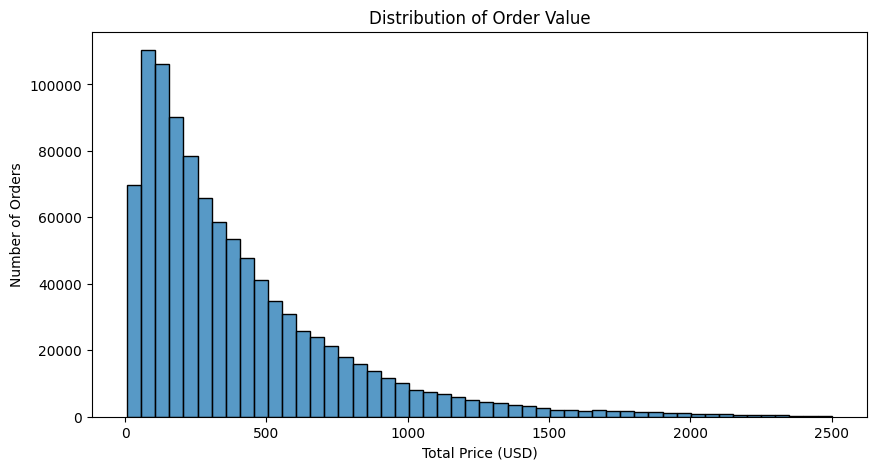

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['total_price_usd'].dropna(),
    bins=50
)

plt.title('Distribution of Order Value')
plt.xlabel('Total Price (USD)')
plt.ylabel('Number of Orders')
plt.show()

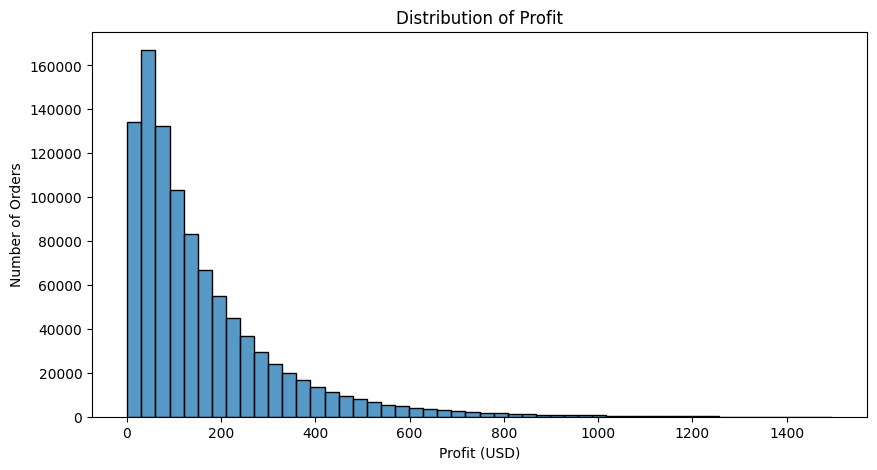

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['profit_usd'].dropna(),
    bins=50
)

plt.title('Distribution of Profit')
plt.xlabel('Profit (USD)')
plt.ylabel('Number of Orders')
plt.show()